# Activation Functions and Loss Functions Lab

This notebook demonstrates:

1. Activation functions over the range $[-10, 10]$.
2. Their derivatives and the resulting curve behaviour.
3. Common loss functions used in regression, classification, and similarity-based learning.

Softmax is vector-valued, so its derivative is a Jacobian. To keep the plots readable, the notebook uses a two-class slice with logits `[0, x]` and plots the class probabilities and their derivatives with respect to `x`.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from math import erf

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def tanh(x):
    return np.tanh(x)


def relu(x):
    return np.maximum(0, x)


def gelu(x):
    return 0.5 * x * (1 + np.vectorize(erf)(x / np.sqrt(2)))


def elu(x, alpha=1.0):
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))


def swish(x):
    return x * sigmoid(x)


def softmax_2class(x):
    logits = np.vstack([np.zeros_like(x), x])
    logits = logits - np.max(logits, axis=0, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=0, keepdims=True)


def dsigmoid(x):
    s = sigmoid(x)
    return s * (1 - s)


def dtanh(x):
    t = np.tanh(x)
    return 1 - t**2


def drelu(x):
    return (x > 0).astype(float)


def dgelu(x):
    return 0.5 * (1 + np.vectorize(erf)(x / np.sqrt(2))) + (x * np.exp(-0.5 * x**2)) / np.sqrt(2 * np.pi)


def delu(x, alpha=1.0):
    return np.where(x > 0, 1.0, alpha * np.exp(x))


def dswish(x):
    s = sigmoid(x)
    return s + x * s * (1 - s)


def dsoftmax_2class(x):
    probs = softmax_2class(x)
    p0 = probs[0]
    p1 = probs[1]
    return -p0 * p1, p0 * p1


x = np.linspace(-10, 10, 1000)


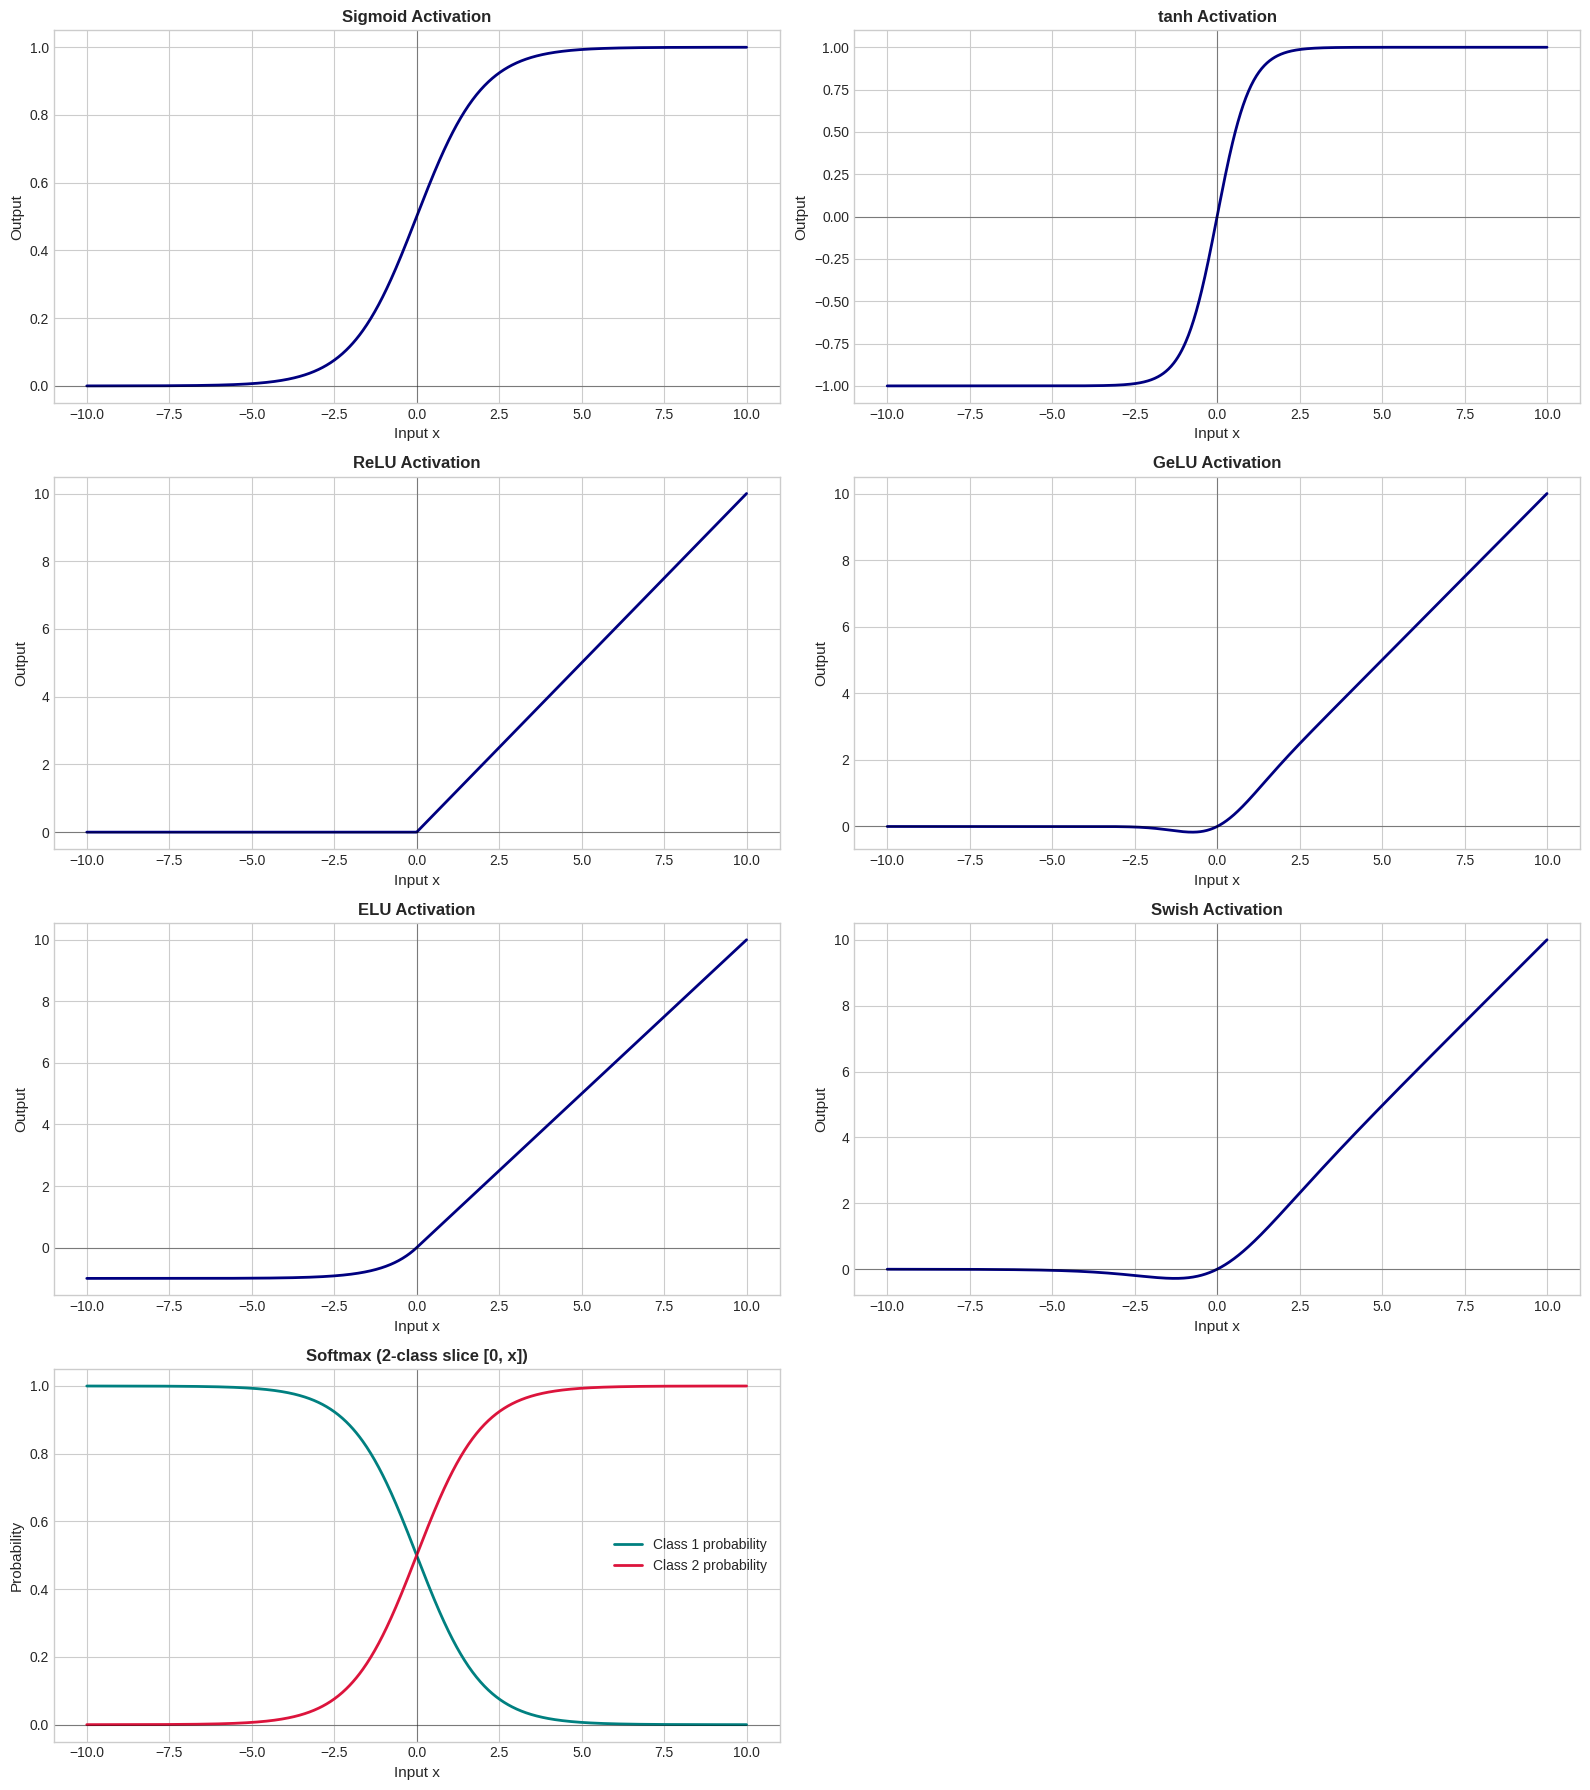

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.ravel()

activation_curves = [
    ('Sigmoid', sigmoid(x)),
    ('tanh', tanh(x)),
    ('ReLU', relu(x)),
    ('GeLU', gelu(x)),
    ('ELU', elu(x)),
    ('Swish', swish(x)),
]

for ax, (name, values) in zip(axes, activation_curves):
    ax.plot(x, values, color='navy', linewidth=2)
    ax.set_title(f'{name} Activation')
    ax.set_xlabel('Input x')
    ax.set_ylabel('Output')
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.4)
    ax.axvline(0, color='black', linewidth=0.8, alpha=0.4)

softmax_probs = softmax_2class(x)
axes[6].plot(x, softmax_probs[0], label='Class 1 probability', color='teal', linewidth=2)
axes[6].plot(x, softmax_probs[1], label='Class 2 probability', color='crimson', linewidth=2)
axes[6].set_title('Softmax (2-class slice [0, x])')
axes[6].set_xlabel('Input x')
axes[6].set_ylabel('Probability')
axes[6].legend()
axes[6].axhline(0, color='black', linewidth=0.8, alpha=0.4)
axes[6].axvline(0, color='black', linewidth=0.8, alpha=0.4)

axes[7].axis('off')
plt.tight_layout()
plt.show()

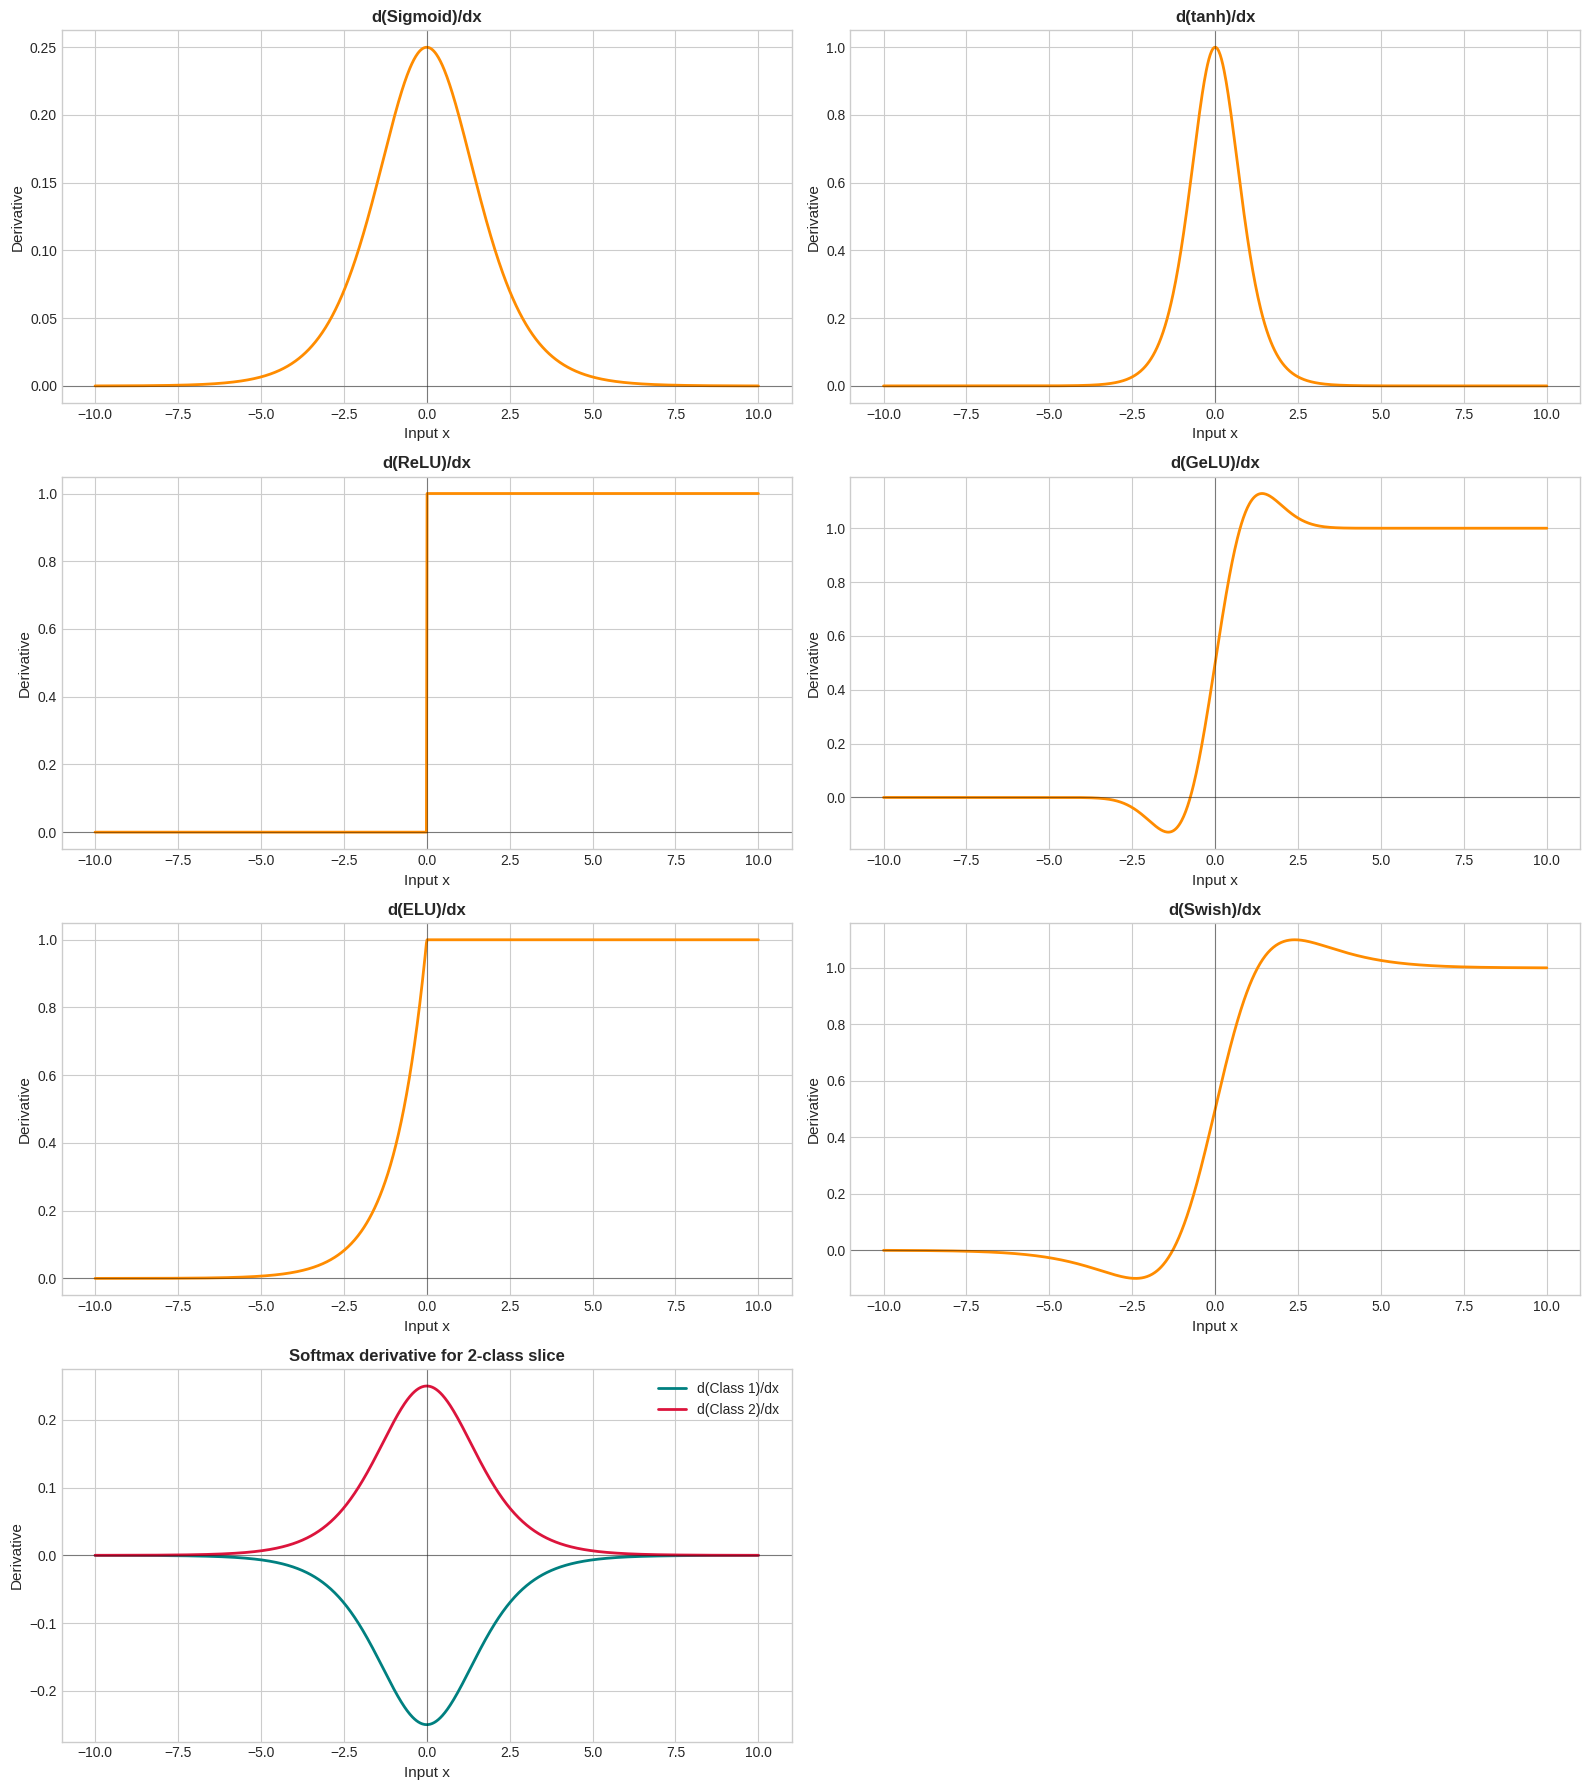

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.ravel()

derivative_curves = [
    ('d(Sigmoid)/dx', dsigmoid(x)),
    ('d(tanh)/dx', dtanh(x)),
    ('d(ReLU)/dx', drelu(x)),
    ('d(GeLU)/dx', dgelu(x)),
    ('d(ELU)/dx', delu(x)),
    ('d(Swish)/dx', dswish(x)),
]

for ax, (name, values) in zip(axes, derivative_curves):
    ax.plot(x, values, color='darkorange', linewidth=2)
    ax.set_title(name)
    ax.set_xlabel('Input x')
    ax.set_ylabel('Derivative')
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.4)
    ax.axvline(0, color='black', linewidth=0.8, alpha=0.4)

softmax_d0, softmax_d1 = dsoftmax_2class(x)
axes[6].plot(x, softmax_d0, label='d(Class 1)/dx', color='teal', linewidth=2)
axes[6].plot(x, softmax_d1, label='d(Class 2)/dx', color='crimson', linewidth=2)
axes[6].set_title('Softmax derivative for 2-class slice')
axes[6].set_xlabel('Input x')
axes[6].set_ylabel('Derivative')
axes[6].legend()
axes[6].axhline(0, color='black', linewidth=0.8, alpha=0.4)
axes[6].axvline(0, color='black', linewidth=0.8, alpha=0.4)

axes[7].axis('off')
plt.tight_layout()
plt.show()

In [6]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def huber_loss(y_true, y_pred, delta=1.0):
    error = y_true - y_pred
    abs_error = np.abs(error)
    quadratic = 0.5 * error**2
    linear = delta * (abs_error - 0.5 * delta)
    return np.mean(np.where(abs_error <= delta, quadratic, linear))


def binary_cross_entropy(y_true, y_pred, eps=1e-12):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


def categorical_cross_entropy(y_true, y_pred, eps=1e-12):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))


def kl_divergence(q, p, eps=1e-12):
    q = np.clip(q, eps, 1)
    p = np.clip(p, eps, 1)
    return np.sum(q * np.log(q / p))


def cosine_similarity_loss(a, b, eps=1e-12):
    numerator = np.dot(a, b)
    denominator = (np.linalg.norm(a) * np.linalg.norm(b)) + eps
    cosine_similarity = numerator / denominator
    return 1 - cosine_similarity


y_true = np.array([3.0, -0.5, 2.0, 7.0])
y_pred = np.array([2.5, 0.0, 2.0, 8.0])

print('Regression-style losses')
print(f'MSE:  {mse(y_true, y_pred):.6f}')
print(f'MAE:  {mae(y_true, y_pred):.6f}')
print(f'Huber (delta=1.0): {huber_loss(y_true, y_pred, delta=1.0):.6f}')
print(f'Cosine Similarity Loss: {cosine_similarity_loss(y_true, y_pred):.6f}')


y_true_bin = np.array([1, 0, 1, 1])
y_pred_bin = np.array([0.9, 0.2, 0.8, 0.7])
print('\nClassification losses')
print(f'Binary Cross-Entropy: {binary_cross_entropy(y_true_bin, y_pred_bin):.6f}')

y_true_cat = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1],
])
y_pred_cat = np.array([
    [0.70, 0.20, 0.10],
    [0.10, 0.80, 0.10],
    [0.20, 0.20, 0.60],
])
print(f'Categorical Cross-Entropy: {categorical_cross_entropy(y_true_cat, y_pred_cat):.6f}')

q = np.array([0.50, 0.30, 0.20])
p = np.array([0.60, 0.25, 0.15])
print(f'KL(q || p): {kl_divergence(q, p):.6f}')

pi = np.array([1.0, 2.0, 3.0])
reference = np.array([2.0, 1.0, 0.5])
print(f'CS Loss for array pi: {cosine_similarity_loss(pi, reference):.6f}')

Regression-style losses
MSE:  0.375000
MAE:  0.500000
Huber (delta=1.0): 0.187500
Cosine Similarity Loss: 0.007145

Classification losses
Binary Cross-Entropy: 0.227081
Categorical Cross-Entropy: 0.363548
KL(q || p): 0.021072
CS Loss for array pi: 0.358467


## Stochastic Gradient Descent and Weight Updates

This batch shows online weight updates for a tiny binary classification dataset.

- Perceptron update uses a hard decision rule.
- Sigmoid update uses logistic loss with stochastic gradient descent.
- The printed losses let you compare how the two updates behave sample by sample.

Perceptron SGD updates
Epoch 1
  Sample 1: activation=0.000, pred=1, loss=0.000, w=[0. 0.], b=0.000
  Sample 2: activation=0.000, pred=1, loss=0.000, w=[0. 0.], b=0.000
  Sample 3: activation=0.000, pred=1, loss=0.000, w=[0.1  0.15], b=-0.100
  Sample 4: activation=-0.150, pred=-1, loss=0.000, w=[0.1  0.15], b=-0.100
Epoch 2
  Sample 1: activation=0.250, pred=1, loss=0.000, w=[0.1  0.15], b=-0.100
  Sample 2: activation=-0.025, pred=-1, loss=0.025, w=[0.25 0.1 ], b=0.000
  Sample 3: activation=-0.400, pred=-1, loss=0.000, w=[0.25 0.1 ], b=0.000
  Sample 4: activation=-0.400, pred=-1, loss=0.000, w=[0.25 0.1 ], b=0.000

Sigmoid SGD updates
Epoch 1
  Sample 1: activation=0.000, p=0.500, L=0.693, w=[0.1  0.05], b=0.050
  Sample 2: activation=0.175, p=0.544, L=0.609, w=[0.1684542  0.02718193], b=0.096
  Sample 3: activation=-0.114, p=0.472, L=0.638, w=[0.21561747 0.09792685], b=0.048
  Sample 4: activation=-0.285, p=0.429, L=0.561, w=[0.30147122 0.05499997], b=0.006
Epoch 2
  Sample 1: act

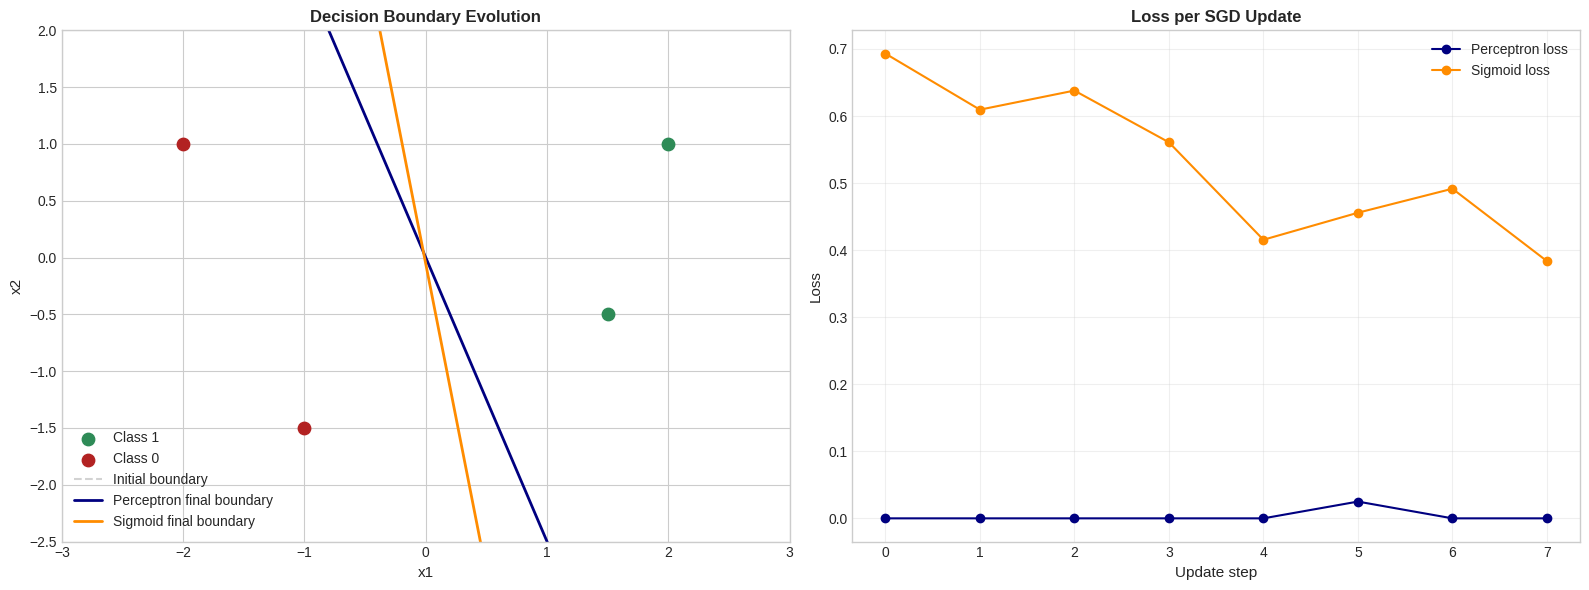


Final learned parameters
Perceptron: w=[0.25 0.1 ], b=0.000
Sigmoid:    w=[0.5269262  0.09708433], b=0.005


In [7]:
X = np.array([
    [2.0, 1.0],
    [1.5, -0.5],
    [-1.0, -1.5],
    [-2.0, 1.0],
])
y = np.array([1, 1, 0, 0])
y_pm = np.where(y == 1, 1, -1)


def perceptron_loss(sample_y, activation):
    return max(0.0, -sample_y * activation)


def sigmoid_loss(sample_y, probability, eps=1e-12):
    probability = np.clip(probability, eps, 1 - eps)
    return -(sample_y * np.log(probability) + (1 - sample_y) * np.log(1 - probability))


def perceptron_update(weights, bias, sample_x, sample_y, learning_rate):
    activation = np.dot(weights, sample_x) + bias
    prediction = 1 if activation >= 0 else -1
    if prediction != sample_y:
        weights = weights + learning_rate * sample_y * sample_x
        bias = bias + learning_rate * sample_y
    return weights, bias, activation, prediction, perceptron_loss(sample_y, activation)


def sigmoid_update(weights, bias, sample_x, sample_y, learning_rate):
    activation = np.dot(weights, sample_x) + bias
    probability = sigmoid(activation)
    error = probability - sample_y
    weights = weights - learning_rate * error * sample_x
    bias = bias - learning_rate * error
    return weights, bias, activation, probability, sigmoid_loss(sample_y, probability)


def decision_boundary(weights, bias, x_values):
    if np.isclose(weights[1], 0.0):
        return np.full_like(x_values, np.nan, dtype=float)
    return -(weights[0] * x_values + bias) / weights[1]


learning_rate = 0.1
perceptron_w = np.zeros(X.shape[1])
perceptron_b = 0.0
sigmoid_w = np.zeros(X.shape[1])
sigmoid_b = 0.0
perceptron_loss_history = []
sigmoid_loss_history = []
perceptron_boundary_history = [(perceptron_w.copy(), perceptron_b)]
sigmoid_boundary_history = [(sigmoid_w.copy(), sigmoid_b)]

print('Perceptron SGD updates')
for epoch in range(2):
    print(f'Epoch {epoch + 1}')
    for i, (sample_x, sample_y) in enumerate(zip(X, y_pm), start=1):
        perceptron_w, perceptron_b, activation, prediction, loss_value = perceptron_update(
            perceptron_w,
            perceptron_b,
            sample_x,
            sample_y,
            learning_rate,
        )
        perceptron_loss_history.append(loss_value)
        perceptron_boundary_history.append((perceptron_w.copy(), perceptron_b))
        print(
            f'  Sample {i}: activation={activation:.3f}, pred={prediction}, '
            f'loss={loss_value:.3f}, w={perceptron_w}, b={perceptron_b:.3f}'
        )

print('\nSigmoid SGD updates')
for epoch in range(2):
    print(f'Epoch {epoch + 1}')
    for i, (sample_x, sample_y) in enumerate(zip(X, y), start=1):
        sigmoid_w, sigmoid_b, activation, probability, loss_value = sigmoid_update(
            sigmoid_w,
            sigmoid_b,
            sample_x,
            sample_y,
            learning_rate,
        )
        sigmoid_loss_history.append(loss_value)
        sigmoid_boundary_history.append((sigmoid_w.copy(), sigmoid_b))
        print(
            f'  Sample {i}: activation={activation:.3f}, p={probability:.3f}, '
            f'L={loss_value:.3f}, w={sigmoid_w}, b={sigmoid_b:.3f}'
        )

x_line = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X[y == 1, 0], X[y == 1, 1], color='seagreen', s=80, label='Class 1')
axes[0].scatter(X[y == 0, 0], X[y == 0, 1], color='firebrick', s=80, label='Class 0')

perceptron_final_w, perceptron_final_b = perceptron_boundary_history[-1]
sigmoid_final_w, sigmoid_final_b = sigmoid_boundary_history[-1]
axes[0].plot(x_line, decision_boundary(np.array([1.0, 0.0]), 0.0, x_line), '--', color='gray', alpha=0.35, label='Initial boundary')
axes[0].plot(x_line, decision_boundary(perceptron_final_w, perceptron_final_b, x_line), color='navy', linewidth=2, label='Perceptron final boundary')
axes[0].plot(x_line, decision_boundary(sigmoid_final_w, sigmoid_final_b, x_line), color='darkorange', linewidth=2, label='Sigmoid final boundary')
axes[0].set_title('Decision Boundary Evolution')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')
axes[0].legend()
axes[0].set_xlim(x_line.min(), x_line.max())
axes[0].set_ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)

axes[1].plot(perceptron_loss_history, marker='o', color='navy', label='Perceptron loss')
axes[1].plot(sigmoid_loss_history, marker='o', color='darkorange', label='Sigmoid loss')
axes[1].set_title('Loss per SGD Update')
axes[1].set_xlabel('Update step')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nFinal learned parameters')
print(f'Perceptron: w={perceptron_final_w}, b={perceptron_final_b:.3f}')
print(f'Sigmoid:    w={sigmoid_final_w}, b={sigmoid_final_b:.3f}')